# Placing a MERFISH section in the Allen CCF

The same volume-to-section fit as [the STARmap notebook](starmap-allen3Datlas.ipynb), on a
denser section and a finer raster. It is the simpler of the two to write: this section needs
no anisotropic initialisation, so `initial_slice`, `initial_rotation` and `initial_scale` say
the whole starting guess and `initial_affine` never appears.

STalign's own version of this analysis: [`merfish-allen3Datlas-alignment`](https://github.com/JEFworks-Lab/STalign/blob/b2068edc98974efa54537eca194736e177bbe11d/docs/notebooks/merfish-allen3Datlas-alignment.ipynb).


## Inputs

Cells as a points element, the atlas and its annotation volume as 3D images. The physical
placement lives on the elements, so nothing downstream builds coordinate axes by hand.

In [1]:
import nrrd, numpy as np, pandas as pd, spatialdata as sd
from spatialdata.models import Image3DModel, PointsModel
from spatialdata.transformations import Scale, Sequence, Translation

cells = pd.read_csv('merfish_data/datasets_mouse_brain_map_BrainReceptorShowcase'
                    '_Slice1_Replicate1_cell_metadata_S1R1.csv.gz')
xy = np.c_[cells['center_x'], cells['center_y']].astype(float)

atlas, hdr = nrrd.read('ara_nissl_50.nrrd')       # (z, y, x)
labels, _ = nrrd.read('annotation_50.nrrd')       # same frame, integer structure ids
voxel = tuple(np.diag(hdr['space directions']))

# The second channel is not decoration: the solver regresses the deformed reference onto the
# section before measuring the match, so one channel fits `a + b*I` and two fit
# `a + b*I + c*(I - mean I)**2`. A regression absorbs a rescaling of its input; it cannot
# invent a channel it was never handed.
def reference_channels(volume):
    v = volume[None] / np.mean(np.abs(volume))
    return np.concatenate([v, (v - v.mean()) ** 2])

sdata = sd.SpatialData(
    points={'cells': PointsModel.parse(xy)},
    images={'atlas': Image3DModel.parse(
        reference_channels(atlas.astype(float)), dims=('c', 'z', 'y', 'x'),
        transformations={'global': Sequence([
            Scale(list(voxel), axes=('z', 'y', 'x')),
            Translation(-(np.asarray(atlas.shape) - 1) * np.asarray(voxel) / 2,
                        axes=('z', 'y', 'x')),
        ])},
    )},
)
sdata

/lustre/boost_ai/users/selman.ozleyen/stalign-scratch/stalign-nb-39810330/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SpatialData object
├── Images
│     └── 'atlas': DataArray[czyx] (2, 264, 160, 228)
└── Points
      └── 'cells': DataFrame with shape: (<Delayed>, 2) (2D points)
with coordinate systems:
    ▸ 'global', with elements:
        atlas (Images), cells (Points)

## The section

[`rasterize_points`](https://github.com/selmanozleyen/squidpy/blob/7ff381e961589351779c89219e54cf4081efeb2a/src/squidpy/experimental/im/_rasterize_points.py) turns the centroids into a density image: each cell deposits unit mass
bilinearly, blurred once per scale, so total intensity is exactly the cell count.

In [2]:
from squidpy.experimental.im import rasterize_points, sample_volume

rasterize_points(sdata, 'cells', dx=10.0, blur=1.0, key_added='section')
sdata['section']

<xarray.DataArray 'image' (c: 1, y: 696, x: 995)> Size: 6MB
dask.array<array, shape=(1, 696, 995), dtype=float64, chunksize=(1, 696, 995), chunktype=numpy.ndarray>
Coordinates:
  * c        (c) int64 8B 0
  * y        (y) float64 6kB 0.5 1.5 2.5 3.5 4.5 ... 692.5 693.5 694.5 695.5
  * x        (x) float64 8kB 0.5 1.5 2.5 3.5 4.5 ... 991.5 992.5 993.5 994.5
Attributes:
    transform:  {'global': Sequence \n    Scale (y, x)\n        [10. 10.]\n  ...

### Putting the section on the scale the solver's parameters assume

`sigmaM`, `sigmaA`, `sigmaB`, `muA` and `muB` are all in the **target's** intensity units, and
upstream states its values against a mean-normalised section. Handing over the raw raster
instead leaves every one of those widths wrong by the raster's own mean -- which for a `dx=10`
raster is a factor of nine, enough to flatten the artifact/background/matching split into
near-constants and leave the fit with almost no gradient to descend.

In [3]:
from spatialdata.models import Image2DModel
from spatialdata.transformations import get_transformation

def mean_normalised(sdata, key):
    element = sdata.images[key]
    values = np.asarray(element)
    sdata.images[key] = Image2DModel.parse(
        values / np.abs(values).mean(), dims=('c', 'y', 'x'),
        transformations={'global': get_transformation(element, 'global')},
    )

mean_normalised(sdata, 'section')
section = np.asarray(sdata['section']).squeeze()
print(f'section now spans {section.min():.2f} to {section.max():.2f}, mean {section.mean():.2f}')

section now spans 0.00 to 7.35, mean 1.00


## The fit

The section is close to coronal and close to atlas scale, so the initialisation is three
numbers: which slice to centre on, how far to rotate in plane, and one uniform scale.

Upstream also nudges the starting translation by a single landmark pair, worth about 42 um in
`x` and 7 um in `y` -- four pixels and under one. That is an initialisation, not an answer, and
the next cell checks the initialisation directly, so it is left out here rather than
reintroducing a hand-built affine to carry it.

In [4]:
from squidpy.experimental.tl import stalign_align_volume

slice_index, rotation, scale = 177, 0.0, 0.9

# Upstream's own values, now that the section is on the scale they were written for. One
# channel, not three: upstream passes `muA=[3, 3, 3]` against a single-channel target and sums
# over the broadcast axis, making its effective widths sigma/sqrt(3) -- divergence D13.
#
# `a` and `sigmaR` are set rather than left to the defaults, from a 3x3 sweep over
# a in {250, 500, 1000} and sigmaR in {1e5, 1e6, 1e7}. A 250 um kernel resolves the
# hippocampal arcs and cortical laminae visibly better than the 500 um default, and at
# sigmaR 1e5 it is the only sweep point that keeps every region the default assigns --
# 163 against 161, none lost -- while agreeing with it on 86% of the 78329 cells. The
# looser sigmaR 1e7 looked sharper still but dropped all of lateral auditory cortex
# (AUDv5, AUDpo5, AUDp1 and six more) to zero cells, which reads as the section's edge
# leaving the annotated volume rather than a real difference in detail.
#
# Upstream's `LDDMM_3D_to_slice` declares sigmaR 1e8, which weights the regulariser so
# weakly against squidpy's corrected rank-3 energy that the velocity field grows
# unchecked; 1e5 here is two orders below squidpy's own 1e6 default, not near upstream's.
SOLVER = dict(a=250.0, sigmaR=1e5, nt=4, sigmaM=2.0, sigmaA=2.0, sigmaB=2.0, muA=[3.0], muB=[0.0])

In [5]:
fit = stalign_align_volume(
    sdata, image_key=('atlas', 'section'), niter=2000,
    initial_slice=slice_index, initial_rotation=rotation, initial_scale=scale, **SOLVER,
)
print(f'{fit.n_iter} iterations, objective '
      f'{float(fit.energies[0]):.0f} -> {float(fit.energies[-1]):.0f}')

2000 iterations, objective 27013 -> 32774


## Convergence

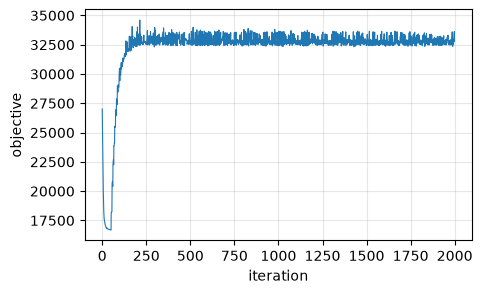

In [6]:
import matplotlib.pyplot as plt

energies = np.asarray(fit.energies)[: fit.n_iter]
plt.figure(figsize=(5, 3))
plt.plot(energies, lw=0.8)
plt.xlabel('iteration'); plt.ylabel('objective'); plt.grid(alpha=0.3)

## Where each cell lands

[`StalignFit.transform_points`](https://github.com/selmanozleyen/squidpy/blob/7ff381e961589351779c89219e54cf4081efeb2a/src/squidpy/experimental/tl/_align/_stalign.py) maps `(x, y)` section coordinates to `(x, y, z)` reference coordinates, evaluated at
each point rather than at the nearest raster cell. [`sample_volume`](https://github.com/selmanozleyen/squidpy/blob/7ff381e961589351779c89219e54cf4081efeb2a/src/squidpy/experimental/im/_rasterize_points.py) then reads the annotation
volume there -- `order=0` because structure ids must not be interpolated.

In [7]:
coords = np.asarray(fit.transform_points(xy))  # (N, 3), (x, y, z) in microns
structure_id = sample_volume(labels, fit.ref_axes, coords, order=0).astype(int)

print(f'{len(coords)} cells placed, {np.unique(structure_id).size} distinct structures, '
      f'{100 * (structure_id == 0).mean():.1f}% outside any annotated structure')
print(f'depth (z) spans {coords[:, 2].min():.0f} to {coords[:, 2].max():.0f} um')

78329 cells placed, 134 distinct structures, 3.7% outside any annotated structure
depth (z) spans 2366 to 2534 um


Structure ids become acronyms through the Allen ontology.

In [8]:
ontology = pd.read_csv('allen_ontology.csv').set_index('id')['acronym']
acronym = pd.Series(structure_id).map(ontology).fillna('unassigned')
acronym.value_counts().head(12)

ProS          4729
DG-mo         4376
MRN           4263
MB            3527
unassigned    2909
PAG           2749
SCig          2676
PG            2504
SCiw          2372
POST          2186
VISp2/3       2031
root          1642
Name: count, dtype: int64

## The aligned atlas over the section

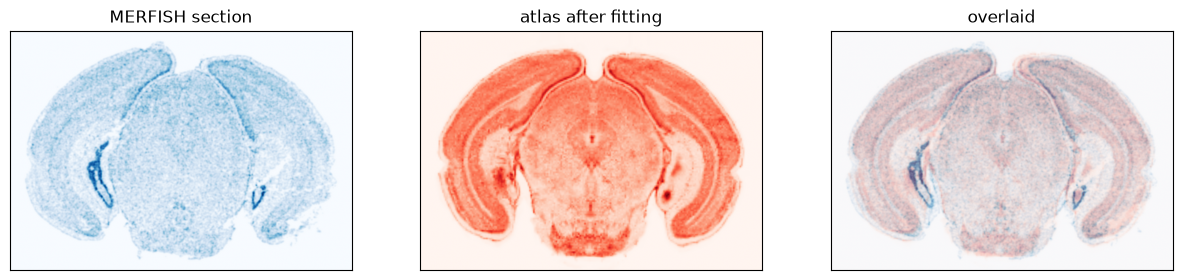

In [9]:
import matplotlib as mpl
from matplotlib.lines import Line2D

def atlas_at(result):
    plane = np.moveaxis(np.asarray(result.deformation_grid(direction='backward')), 0, -1)[0]
    sampled = sample_volume(atlas, result.ref_axes, plane.reshape(-1, 3)[:, ::-1])
    return sampled.reshape(plane.shape[:2])

section = np.asarray(sdata['section']).squeeze()
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(section, cmap=mpl.cm.Blues)
ax[1].imshow(atlas_at(fit), cmap=mpl.cm.Reds)
ax[2].imshow(section, cmap=mpl.cm.Blues, alpha=0.9)
ax[2].imshow(atlas_at(fit), cmap=mpl.cm.Reds, alpha=0.3)
for a, t in zip(ax, ('MERFISH section', 'atlas after fitting', 'overlaid'), strict=True):
    a.set_title(t); a.set_xticks([]); a.set_yticks([])

## Cells coloured by structure

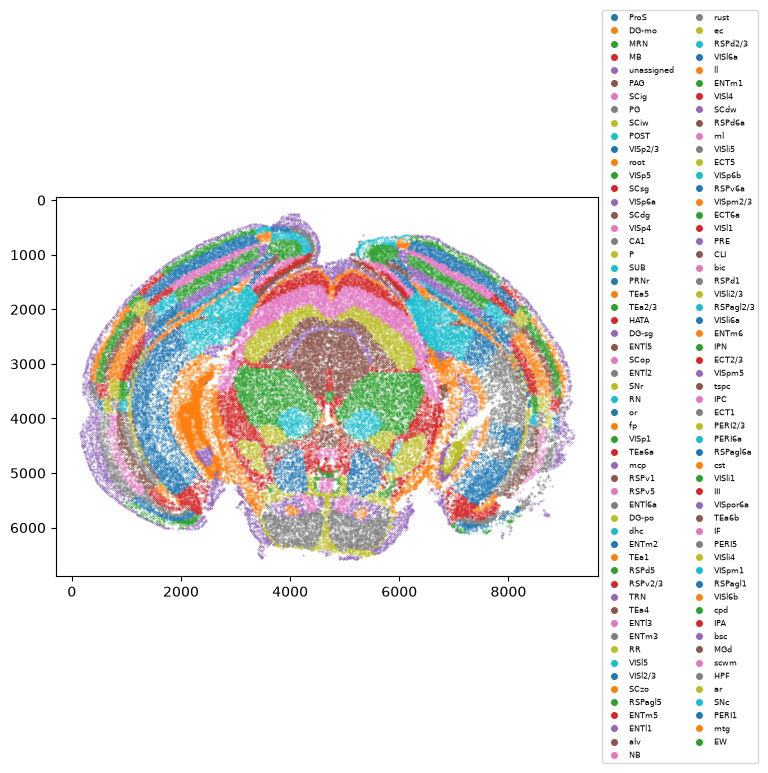

In [10]:
keep = acronym.value_counts()
keep = keep[keep >= 50].index                       # a legend of singletons reads as noise
fig, ax = plt.subplots(figsize=(7, 6))
for region in keep:
    m = (acronym == region).to_numpy()
    ax.scatter(xy[m, 0], xy[m, 1], s=0.08, label=region)
ax.invert_yaxis(); ax.set_aspect('equal')
ax.legend(handles=[Line2D([], [], marker='o', ls='', ms=4, color=h.get_facecolor()[0], label=r)
                   for r, h in zip(keep, ax.collections, strict=True)],
          fontsize=6, ncol=2, loc='center left', bbox_to_anchor=(1, 0.5))